<a href="https://www.kaggle.com/code/mubashirulhassan00/week-1-data-quality-report?scriptVersionId=333593803" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

**Intern:** Mubashir Ul Hassan
**Team:** Research / ML / AI — ARIMA Sub-team  
**Dataset:** 240K+ Household Electricity Consumption Records  
**Source:** [Kaggle](https://www.kaggle.com/datasets/thedevastator/240000-household-electricity-consumption-records)  

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset
df = pd.read_csv('/kaggle/input/datasets/thedevastator/240000-household-electricity-consumption-records/household_power_consumption.csv')

In [3]:
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (260640, 10)
Columns: ['index', 'Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


,index,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,0,1/1/07,0:00:00,2.58,0.136,241.97,10.6,0,0,0.0
1,1,1/1/07,0:01:00,2.552,0.1,241.75,10.4,0,0,0.0
2,2,1/1/07,0:02:00,2.55,0.1,241.64,10.4,0,0,0.0
3,3,1/1/07,0:03:00,2.55,0.1,241.71,10.4,0,0,0.0
4,4,1/1/07,0:04:00,2.554,0.1,241.98,10.4,0,0,0.0


In [4]:
# CELL 3: Fix Data Types & Create Timestamp
df['timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='mixed', dayfirst=True)

numeric_cols = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.set_index('timestamp', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)
df.sort_index(inplace=True)

print(f'Time range: {df.index.min()} to {df.index.max()}')
print(f'Duration: ~{(df.index.max() - df.index.min()).days} days')
print(f'Total records: {len(df):,}')
df.head()    

Time range: 2007-01-01 00:00:00 to 2007-06-30 23:59:00
Duration: ~180 days
Total records: 260,640


,index,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
timestamp,,,,,,,,
2007-01-01 00:00:00,0,2.580,0.136,241.97,10.6,0.0,0.0,0.0
2007-01-01 00:01:00,1,2.552,0.100,241.75,10.4,0.0,0.0,0.0
2007-01-01 00:02:00,2,2.550,0.100,241.64,10.4,0.0,0.0,0.0
2007-01-01 00:03:00,3,2.550,0.100,241.71,10.4,0.0,0.0,0.0
2007-01-01 00:04:00,4,2.554,0.100,241.98,10.4,0.0,0.0,0.0


In [5]:
df.shape

(260640, 8)

In [6]:
df.describe()

,index,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,260640.000000,256869.000000,256869.000000,256869.000000,256869.000000,256869.000000,256869.000000,256869.000000
mean,130319.500000,1.164937,0.123729,239.208981,4.974755,1.332481,1.670610,5.831825
std,75240.431418,1.181832,0.111872,3.592793,4.999493,6.704970,6.631361,8.186709
min,0.000000,0.082000,0.000000,223.490000,0.400000,0.000000,0.000000,0.000000
25%,65159.750000,0.296000,0.000000,236.650000,1.400000,0.000000,0.000000,0.000000
50%,130319.500000,0.564000,0.104000,239.610000,2.600000,0.000000,0.000000,0.000000
75%,195479.250000,1.606000,0.194000,241.810000,6.800000,0.000000,1.000000,17.000000
max,260639.000000,10.670000,1.148000,250.890000,46.400000,78.000000,78.000000,20.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 260640 entries, 2007-01-01 00:00:00 to 2007-06-30 23:59:00
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   index                  260640 non-null  int64  
 1   Global_active_power    256869 non-null  float64
 2   Global_reactive_power  256869 non-null  float64
 3   Voltage                256869 non-null  float64
 4   Global_intensity       256869 non-null  float64
 5   Sub_metering_1         256869 non-null  float64
 6   Sub_metering_2         256869 non-null  float64
 7   Sub_metering_3         256869 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 17.9 MB



## SECTION 1: Source Information
## SECTION 2: Time Range & Temporal Resolution

In [8]:
# CELL 4: DQR SECTION 1 & 2
print('=' * 60)
print('SECTION 1: Source Information')
print('=' * 60)
print('Source:    Kaggle — Household Electricity Consumption')
print('URL:      https://www.kaggle.com/datasets/thedevastator/240000-household-electricity-consumption-records')
print('Authors:  Georges Hebrail and Alice Berard')
print('File:     household_power_consumption.csv')

print()
print('=' * 60)
print('SECTION 2: Time Range & Temporal Resolution')
print('=' * 60)
print(f'Start Date:   {df.index.min()}')
print(f'End Date:     {df.index.max()}')
duration_days = (df.index.max() - df.index.min()).days
print(f'Duration:     ~{duration_days} days ({duration_days / 30:.1f} months)')
print(f'Resolution:   1-minute intervals')
print(f'Total Points: {len(df):,}')

SECTION 1: Source Information
Source:    Kaggle — Household Electricity Consumption
URL:      https://www.kaggle.com/datasets/thedevastator/240000-household-electricity-consumption-records
Authors:  Georges Hebrail and Alice Berard
File:     household_power_consumption.csv

SECTION 2: Time Range & Temporal Resolution
Start Date:   2007-01-01 00:00:00
End Date:     2007-06-30 23:59:00
Duration:     ~180 days (6.0 months)
Resolution:   1-minute intervals
Total Points: 260,640


## SECTION 3: All Variables with Descriptions

In [9]:
# CELL 5: DQR SECTION 3

variable_info = {
    'Global_active_power':    'Total active power consumed by household (kilowatts)',
    'Global_reactive_power':  'Total reactive power consumed by household (kilowatts)',
    'Voltage':                'Voltage delivered to household (volts)',
    'Global_intensity':       'Average current intensity delivered (amperes)',
    'Sub_metering_1':         'Kitchen active energy in watt-hours (dishwasher, oven, microwave)',
    'Sub_metering_2':         'Laundry room active energy in watt-hours (washing machine, dryer, light)',
    'Sub_metering_3':         'Electric water heater + air conditioner active energy in watt-hours'
}

for col, desc in variable_info.items():
    non_null = df[col].notna().sum()
    print(f'\n  {col}')
    print(f'     Description : {desc}')
    print(f'     Data Type   : {df[col].dtype}')
    print(f'     Non-null    : {non_null:,} / {len(df):,}')
    print(f'     Range       : [{df[col].min():.3f}  to  {df[col].max():.3f}]')
    print(f'     Mean        : {df[col].mean():.3f}')
    print(f'     Std Dev     : {df[col].std():.3f}')

print(f'\n  Total columns: {len(df.columns)}')


  Global_active_power
     Description : Total active power consumed by household (kilowatts)
     Data Type   : float64
     Non-null    : 256,869 / 260,640
     Range       : [0.082  to  10.670]
     Mean        : 1.165
     Std Dev     : 1.182

  Global_reactive_power
     Description : Total reactive power consumed by household (kilowatts)
     Data Type   : float64
     Non-null    : 256,869 / 260,640
     Range       : [0.000  to  1.148]
     Mean        : 0.124
     Std Dev     : 0.112

  Voltage
     Description : Voltage delivered to household (volts)
     Data Type   : float64
     Non-null    : 256,869 / 260,640
     Range       : [223.490  to  250.890]
     Mean        : 239.209
     Std Dev     : 3.593

  Global_intensity
     Description : Average current intensity delivered (amperes)
     Data Type   : float64
     Non-null    : 256,869 / 260,640
     Range       : [0.400  to  46.400]
     Mean        : 4.975
     Std Dev     : 4.999

  Sub_metering_1
     Description :

## SECTION 4: Missing Value Analysis

               Column  Missing Count Missing Pct Risk Level
                index              0       0.00%        LOW
  Global_active_power           3771       1.45%        LOW
Global_reactive_power           3771       1.45%        LOW
              Voltage           3771       1.45%        LOW
     Global_intensity           3771       1.45%        LOW
       Sub_metering_1           3771       1.45%        LOW
       Sub_metering_2           3771       1.45%        LOW
       Sub_metering_3           3771       1.45%        LOW

Total rows: 260,640
Rows with ANY missing: 3,771 (1.45%)


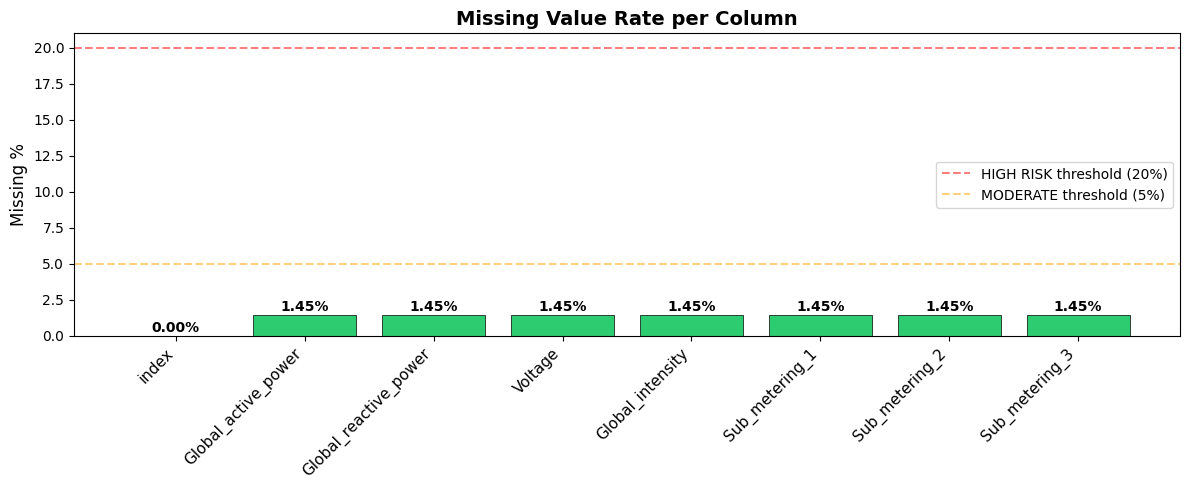

In [10]:
# CELL 6: DQR SECTION 4 — Missing Values

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing Pct': [f'{v:.2f}%' for v in missing_pct.values],
    'Risk Level': ['HIGH RISK' if pct > 20 else 'MODERATE' if pct > 5 else 'LOW' for pct in missing_pct.values]
})
print(missing_df.to_string(index=False))
print(f'\nTotal rows: {len(df):,}')
print(f'Rows with ANY missing: {df.isnull().any(axis=1).sum():,} ({df.isnull().any(axis=1).sum()/len(df)*100:.2f}%)')

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if pct > 20 else '#f39c12' if pct > 5 else '#2ecc71' for pct in missing_pct.values]
bars = ax.bar(missing_pct.index, missing_pct.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, pct in zip(bars, missing_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{pct:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Missing %', fontsize=12)
ax.set_title('Missing Value Rate per Column', fontsize=14, fontweight='bold')
ax.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='HIGH RISK threshold (20%)')
ax.axhline(y=5, color='orange', linestyle='--', alpha=0.5, label='MODERATE threshold (5%)')
ax.legend(fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.tight_layout()

plt.savefig('/kaggle/working/dqr_section4_missing_values.png',
            dpi=300, bbox_inches='tight')

plt.show()

In [11]:
# CELL 7: Descriptive Statistics
df.describe().round(3)

,index,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,260640.000,256869.000,256869.000,256869.000,256869.000,256869.000,256869.000,256869.000
mean,130319.500,1.165,0.124,239.209,4.975,1.332,1.671,5.832
std,75240.431,1.182,0.112,3.593,4.999,6.705,6.631,8.187
min,0.000,0.082,0.000,223.490,0.400,0.000,0.000,0.000
25%,65159.750,0.296,0.000,236.650,1.400,0.000,0.000,0.000
50%,130319.500,0.564,0.104,239.610,2.600,0.000,0.000,0.000
75%,195479.250,1.606,0.194,241.810,6.800,0.000,1.000,17.000
max,260639.000,10.670,1.148,250.890,46.400,78.000,78.000,20.000


## SECTION 5: Anomaly Detection

In [12]:
# CELL 8: DQR SECTION 5 — Anomaly Detection

anomalies = []

# --- Anomaly 1: Negative power values ---
neg_power = df[df['Global_active_power'] < 0]
print(f'\nAnomaly Check 1: Negative Global_active_power')
print(f'   Found: {len(neg_power)} instances')
if len(neg_power) > 0:
    anomalies.append(('Negative active power', len(neg_power),
                       'Physically impossible - power consumption cannot be negative'))
    print(f'   ANOMALY detected!')
    print(neg_power.head(3))
else:
    print('   None found - PASS')

# --- Anomaly 2: Extreme voltage ---
print(f'\nAnomaly Check 2: Extreme Voltage (<200V or >260V)')
voltage_low = df[df['Voltage'] < 200]
voltage_high = df[df['Voltage'] > 260]
total_voltage_anom = len(voltage_low) + len(voltage_high)
print(f'   Voltage < 200V: {len(voltage_low)} instances')
print(f'   Voltage > 260V: {len(voltage_high)} instances')
print(f'   Min voltage: {df["Voltage"].min():.2f}V | Max voltage: {df["Voltage"].max():.2f}V')
if total_voltage_anom > 0:
    anomalies.append(('Extreme voltage readings', total_voltage_anom,
                       'European household ~230V +/-10%. Values outside 200-260V are suspicious'))
    print(f'   ANOMALY - {total_voltage_anom} readings outside normal range')
else:
    print('   All within normal range - PASS')

# --- Anomaly 3: Statistical outliers (IQR method) ---
print(f'\nAnomaly Check 3: Statistical Outliers (3xIQR) - Global_active_power')
Q1 = df['Global_active_power'].quantile(0.25)
Q3 = df['Global_active_power'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR
outliers = df[(df['Global_active_power'] < lower_bound) | (df['Global_active_power'] > upper_bound)]
print(f'   Q1={Q1:.3f}, Q3={Q3:.3f}, IQR={IQR:.3f}')
print(f'   Bounds: [{lower_bound:.3f}, {upper_bound:.3f}] kW')
print(f'   Outliers: {len(outliers)} instances ({len(outliers)/len(df)*100:.2f}%)')
anomalies.append(('IQR outliers (active power)', len(outliers),
                   f'Values outside [{lower_bound:.2f}, {upper_bound:.2f}] kW'))

# --- Anomaly 4: Extreme power spikes ---
print(f'\nAnomaly Check 4: Extreme Power Spikes')
p99 = df['Global_active_power'].quantile(0.99)
extreme_spikes = df[df['Global_active_power'] > p99 * 1.5]
print(f'   99th percentile: {p99:.3f} kW')
print(f'   Threshold (1.5x p99): {p99 * 1.5:.3f} kW')
print(f'   Extreme spikes: {len(extreme_spikes)} instances')
if len(extreme_spikes) > 0:
    anomalies.append(('Extreme power spikes', len(extreme_spikes),
                       f'Values > {p99*1.5:.2f} kW (1.5x the 99th percentile)'))
    print(f'   Max recorded: {df["Global_active_power"].max():.3f} kW')

# --- Anomaly 5: Time gaps ---
print(f'\nAnomaly Check 5: Time Series Gaps (> 5 minutes)')
time_diffs = df.index.to_series().diff()
large_gaps = time_diffs[time_diffs > pd.Timedelta(minutes=5)]
print(f'   Gaps found: {len(large_gaps)}')
if len(large_gaps) > 0:
    anomalies.append(('Time series gaps (>5 min)', len(large_gaps),
                       f'Largest gap: {large_gaps.max()}. Missing recordings indicate sensor downtime'))
    print(f'   Largest gap: {large_gaps.max()}')
    print(f'   Top 5 gaps:')
    for ts, gap in large_gaps.nlargest(5).items():
        print(f'      {ts} -- gap of {gap}')
else:
    print('   No significant gaps - PASS')

# --- Anomaly 6: Zero consumption ---
print(f'\nAnomaly Check 6: Zero Active Power (consumption = 0)')
zero_power = df[df['Global_active_power'] == 0]
print(f'   Zero-power readings: {len(zero_power)} ({len(zero_power)/len(df)*100:.2f}%)')
if len(zero_power) > 100:
    anomalies.append(('Zero power readings', len(zero_power),
                       'Extended zero consumption may indicate sensor failure or vacancy'))

# --- Summary ---
print('\n' + '=' * 60)
print(f'ANOMALY SUMMARY - {len(anomalies)} types identified:')
print('=' * 60)
for i, (name, count, reason) in enumerate(anomalies, 1):
    print(f'  {i}. {name}')
    print(f'     Count: {count:,} instances')
    print(f'     Reason: {reason}')
    print()


Anomaly Check 1: Negative Global_active_power
   Found: 0 instances
   None found - PASS

Anomaly Check 2: Extreme Voltage (<200V or >260V)
   Voltage < 200V: 0 instances
   Voltage > 260V: 0 instances
   Min voltage: 223.49V | Max voltage: 250.89V
   All within normal range - PASS

Anomaly Check 3: Statistical Outliers (3xIQR) - Global_active_power
   Q1=0.296, Q3=1.606, IQR=1.310
   Bounds: [-3.634, 5.536] kW
   Outliers: 2075 instances (0.80%)

Anomaly Check 4: Extreme Power Spikes
   99th percentile: 5.322 kW
   Threshold (1.5x p99): 7.983 kW
   Extreme spikes: 52 instances
   Max recorded: 10.670 kW

Anomaly Check 5: Time Series Gaps (> 5 minutes)
   Gaps found: 0
   No significant gaps - PASS

Anomaly Check 6: Zero Active Power (consumption = 0)
   Zero-power readings: 0 (0.00%)

ANOMALY SUMMARY - 2 types identified:
  1. IQR outliers (active power)
     Count: 2,075 instances
     Reason: Values outside [-3.63, 5.54] kW

  2. Extreme power spikes
     Count: 52 instances
     R

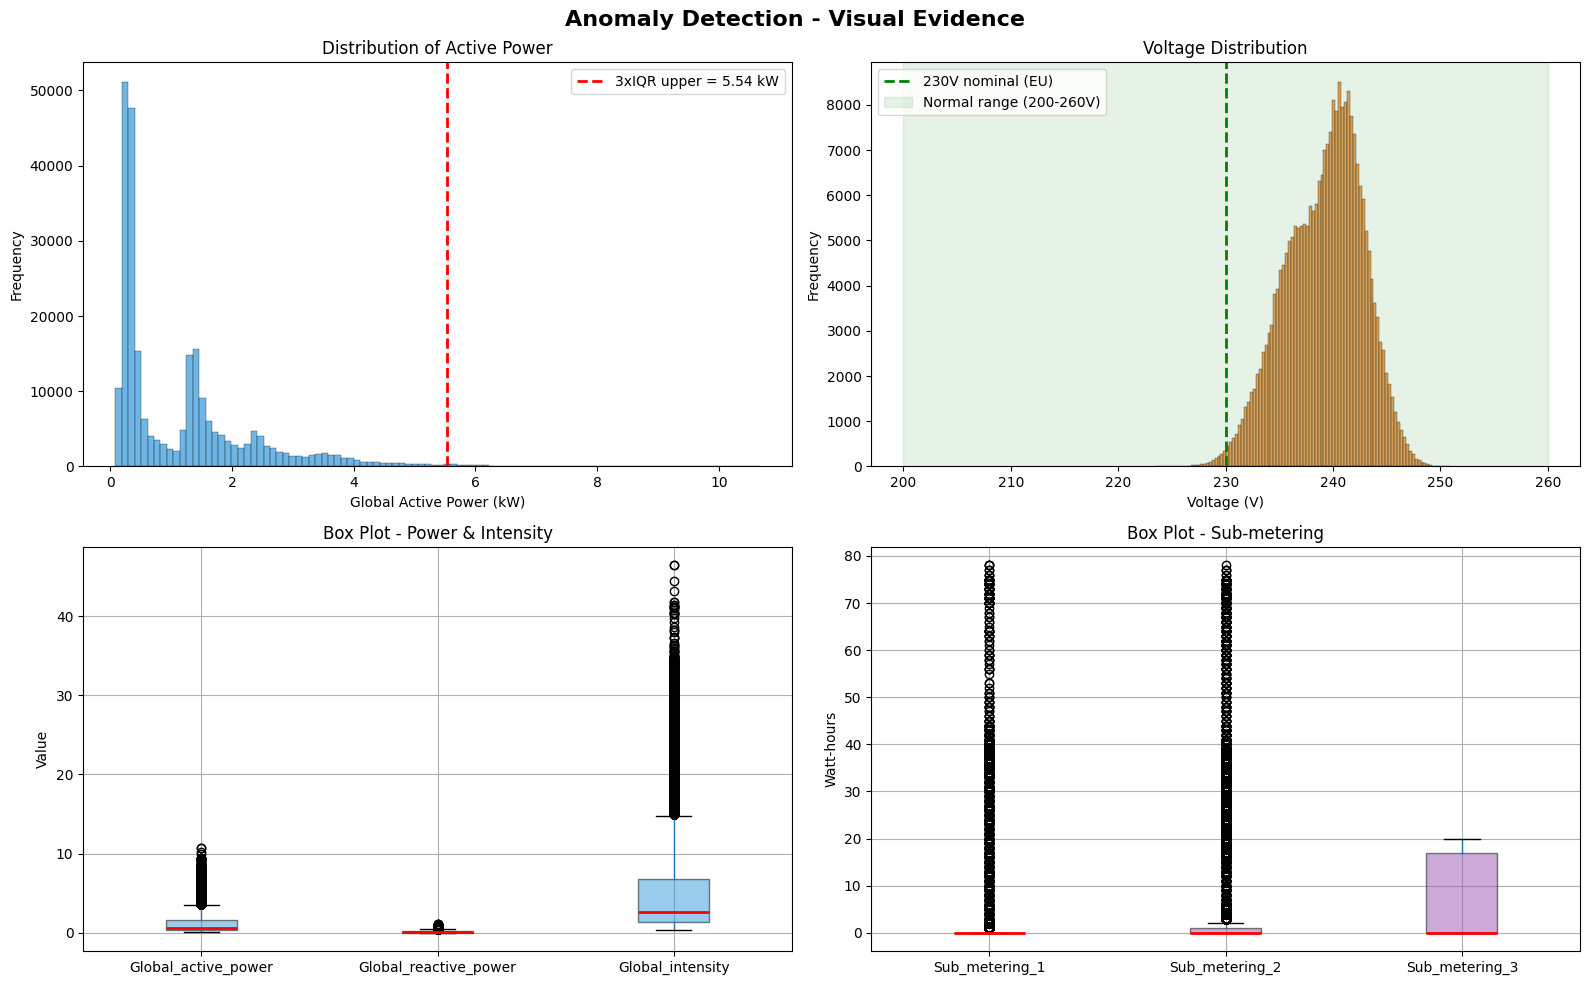

In [13]:
# CELL 9: Anomaly Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Anomaly Detection - Visual Evidence', fontsize=16, fontweight='bold')

# 1. Power distribution with outlier threshold
ax = axes[0, 0]
ax.hist(df['Global_active_power'].dropna(), bins=100, color='#3498db',
        alpha=0.7, edgecolor='black', linewidth=0.3)
ax.axvline(upper_bound, color='red', linestyle='--', linewidth=2,
           label=f'3xIQR upper = {upper_bound:.2f} kW')
ax.set_xlabel('Global Active Power (kW)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Active Power')
ax.legend()

# 2. Voltage distribution
ax = axes[0, 1]
ax.hist(df['Voltage'].dropna(), bins=100, color='#e67e22',
        alpha=0.7, edgecolor='black', linewidth=0.3)
ax.axvline(230, color='green', linestyle='--', linewidth=2, label='230V nominal (EU)')
ax.axvspan(200, 260, alpha=0.1, color='green', label='Normal range (200-260V)')
ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Frequency')
ax.set_title('Voltage Distribution')
ax.legend()

# 3. Box plots - power features
ax = axes[1, 0]
df[['Global_active_power', 'Global_reactive_power', 'Global_intensity']].boxplot(
    ax=ax, patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.5),
    medianprops=dict(color='red', linewidth=2))
ax.set_title('Box Plot - Power & Intensity')
ax.set_ylabel('Value')

# 4. Box plots - sub-metering
ax = axes[1, 1]
df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].boxplot(
    ax=ax, patch_artist=True,
    boxprops=dict(facecolor='#9b59b6', alpha=0.5),
    medianprops=dict(color='red', linewidth=2))
ax.set_title('Box Plot - Sub-metering')
ax.set_ylabel('Watt-hours')

plt.tight_layout()

plt.savefig('/kaggle/working/dqr_section5_anomaly_detection.png',
            dpi=300, bbox_inches='tight')

plt.show()

## SECTION 6: Key Trends Observed

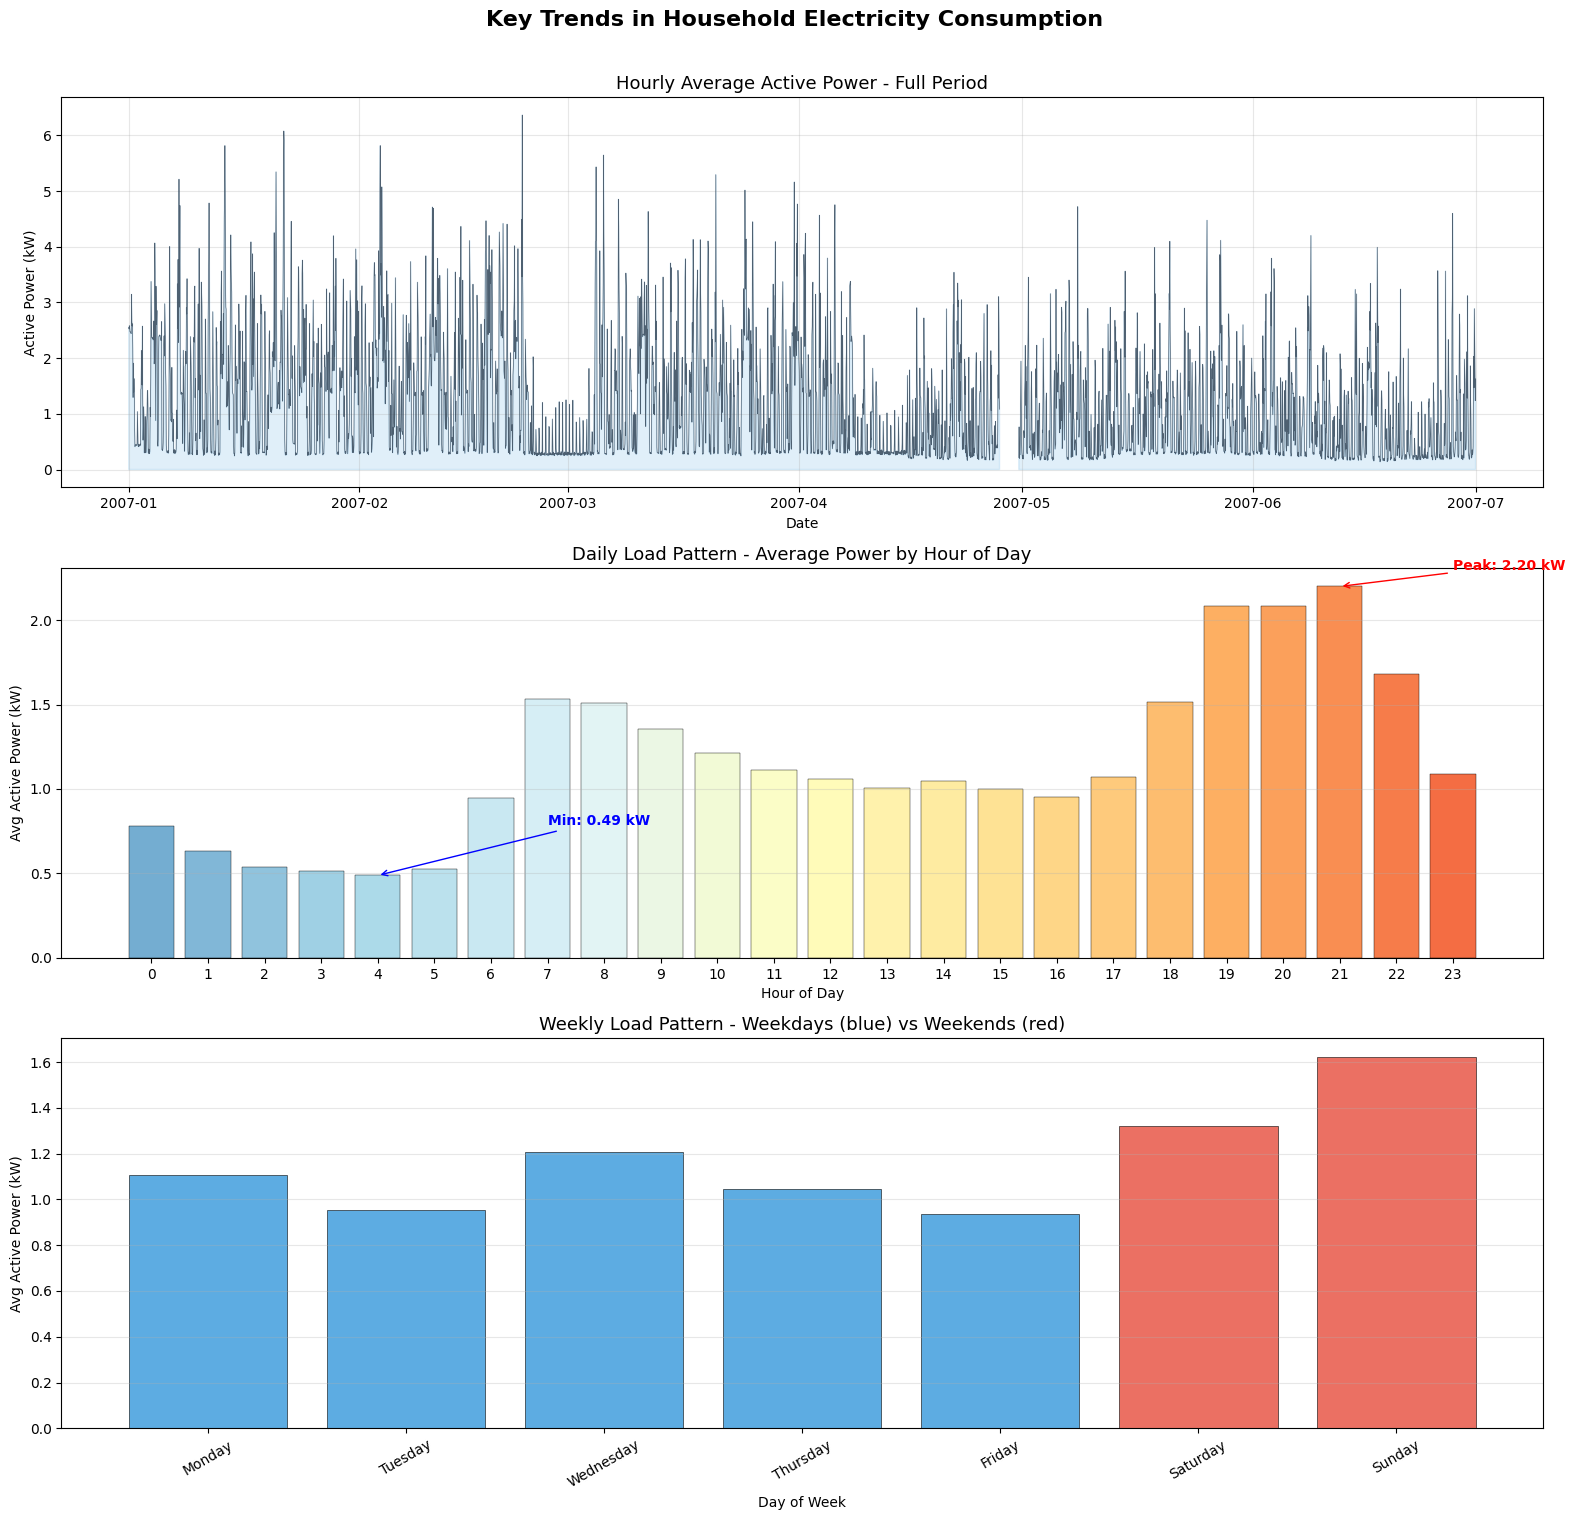

In [14]:
# CELL 10: DQR SECTION 6 — Key Trends (Main Plots)
fig, axes = plt.subplots(3, 1, figsize=(16, 15))
fig.suptitle('Key Trends in Household Electricity Consumption',
             fontsize=16, fontweight='bold', y=1.01)

# --- Plot 1: Overall load over time (hourly average) ---
ax = axes[0]
hourly = df['Global_active_power'].resample('1h').mean()
ax.plot(hourly.index, hourly.values, color='#2c3e50', linewidth=0.5, alpha=0.8)
ax.fill_between(hourly.index, hourly.values, alpha=0.15, color='#3498db')
ax.set_xlabel('Date')
ax.set_ylabel('Active Power (kW)')
ax.set_title('Hourly Average Active Power - Full Period', fontsize=13)
ax.grid(True, alpha=0.3)

# --- Plot 2: Daily load pattern (average by hour) ---
ax = axes[1]
hourly_avg = df.groupby(df.index.hour)['Global_active_power'].mean()
colors_bar = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, 24))
bars = ax.bar(hourly_avg.index, hourly_avg.values, color=colors_bar,
              edgecolor='black', linewidth=0.3)

peak_hour = hourly_avg.idxmax()
min_hour = hourly_avg.idxmin()
ax.annotate(f'Peak: {hourly_avg.max():.2f} kW',
            xy=(peak_hour, hourly_avg.max()),
            xytext=(peak_hour + 2, hourly_avg.max() + 0.1),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red', fontweight='bold')
ax.annotate(f'Min: {hourly_avg.min():.2f} kW',
            xy=(min_hour, hourly_avg.min()),
            xytext=(min_hour + 3, hourly_avg.min() + 0.3),
            arrowprops=dict(arrowstyle='->', color='blue'),
            fontsize=10, color='blue', fontweight='bold')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Active Power (kW)')
ax.set_title('Daily Load Pattern - Average Power by Hour of Day', fontsize=13)
ax.set_xticks(range(24))
ax.grid(True, alpha=0.3, axis='y')

# --- Plot 3: Weekly pattern ---
ax = axes[2]
daily_avg = df.groupby(df.index.dayofweek)['Global_active_power'].mean()
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
bar_colors = ['#3498db'] * 5 + ['#e74c3c'] * 2
bars = ax.bar(range(7), daily_avg.values, color=bar_colors,
              alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Avg Active Power (kW)')
ax.set_title('Weekly Load Pattern - Weekdays (blue) vs Weekends (red)', fontsize=13)
ax.set_xticks(range(7))
ax.set_xticklabels(day_names, rotation=30)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

plt.savefig('/kaggle/working/dqr_section6_key_trends.png',
            dpi=300, bbox_inches='tight')

plt.show()

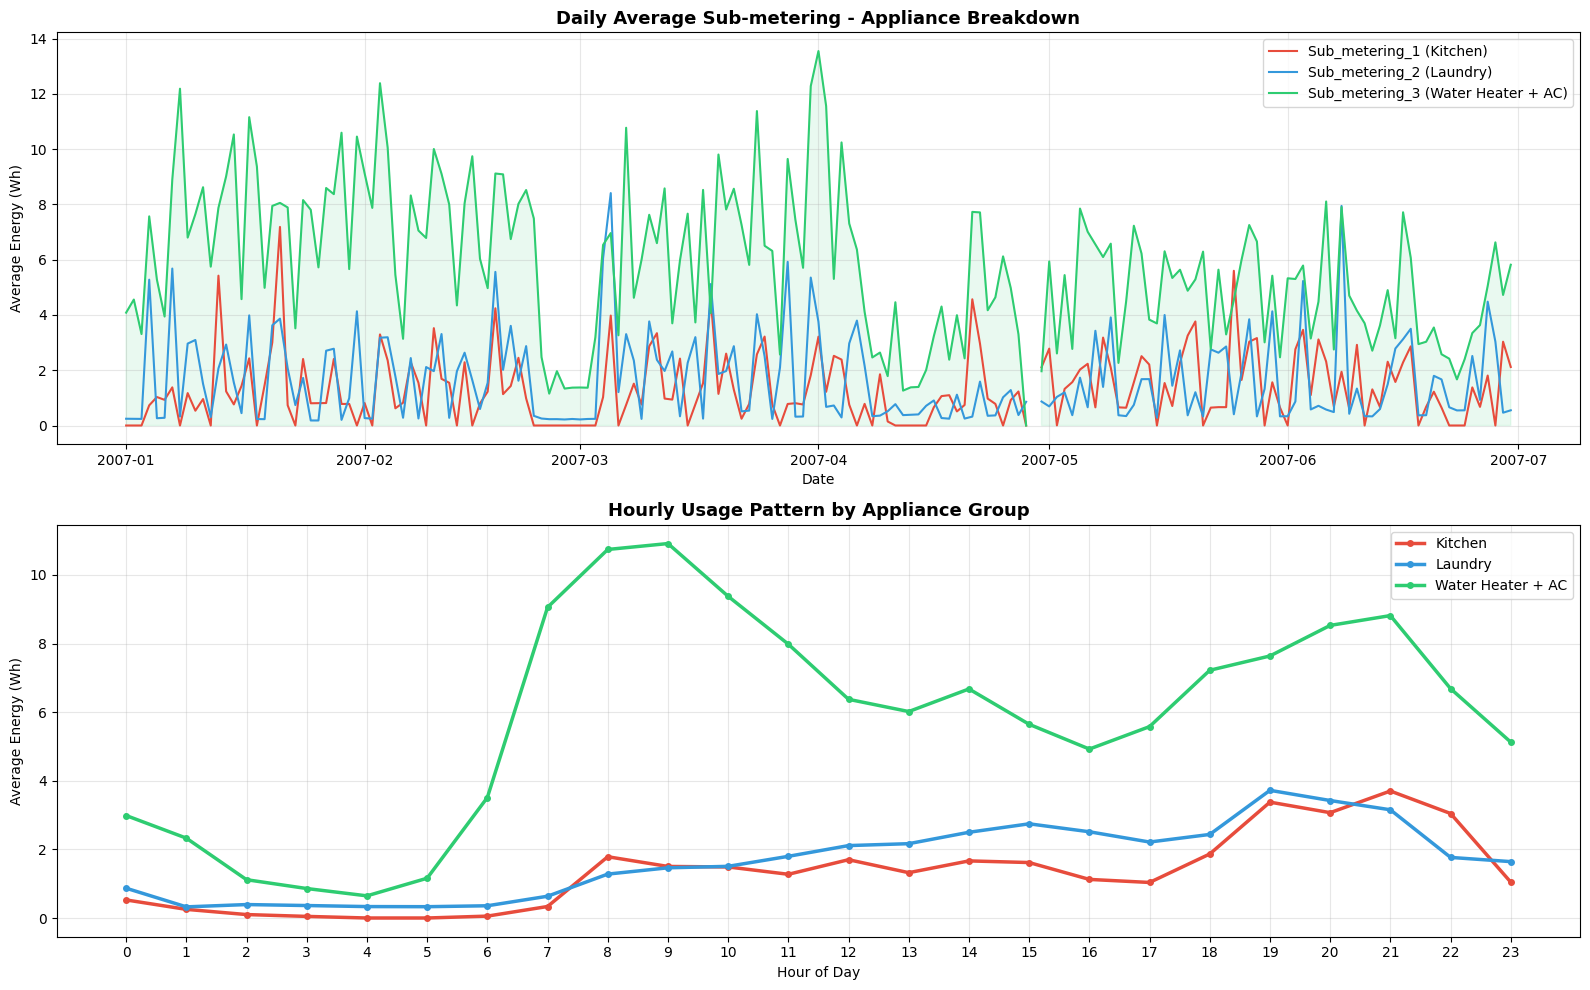

In [15]:
# CELL 11: Sub-metering Breakdown
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Daily average sub-metering over time
ax = axes[0]
daily = df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].resample('1D').mean()
ax.plot(daily.index, daily['Sub_metering_1'], label='Sub_metering_1 (Kitchen)',
        linewidth=1.5, color='#e74c3c')
ax.plot(daily.index, daily['Sub_metering_2'], label='Sub_metering_2 (Laundry)',
        linewidth=1.5, color='#3498db')
ax.plot(daily.index, daily['Sub_metering_3'], label='Sub_metering_3 (Water Heater + AC)',
        linewidth=1.5, color='#2ecc71')
ax.fill_between(daily.index, daily['Sub_metering_3'], alpha=0.1, color='#2ecc71')
ax.set_xlabel('Date')
ax.set_ylabel('Average Energy (Wh)')
ax.set_title('Daily Average Sub-metering - Appliance Breakdown', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Hourly pattern per sub-meter
ax = axes[1]
for col, label, color in [('Sub_metering_1', 'Kitchen', '#e74c3c'),
                           ('Sub_metering_2', 'Laundry', '#3498db'),
                           ('Sub_metering_3', 'Water Heater + AC', '#2ecc71')]:
    hourly_sm = df.groupby(df.index.hour)[col].mean()
    ax.plot(hourly_sm.index, hourly_sm.values, label=label, linewidth=2.5,
            color=color, marker='o', markersize=4)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Energy (Wh)')
ax.set_title('Hourly Usage Pattern by Appliance Group', fontsize=13, fontweight='bold')
ax.set_xticks(range(24))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('/kaggle/working/dqr_section6_daily_average.png',
            dpi=300, bbox_inches='tight')

plt.show()

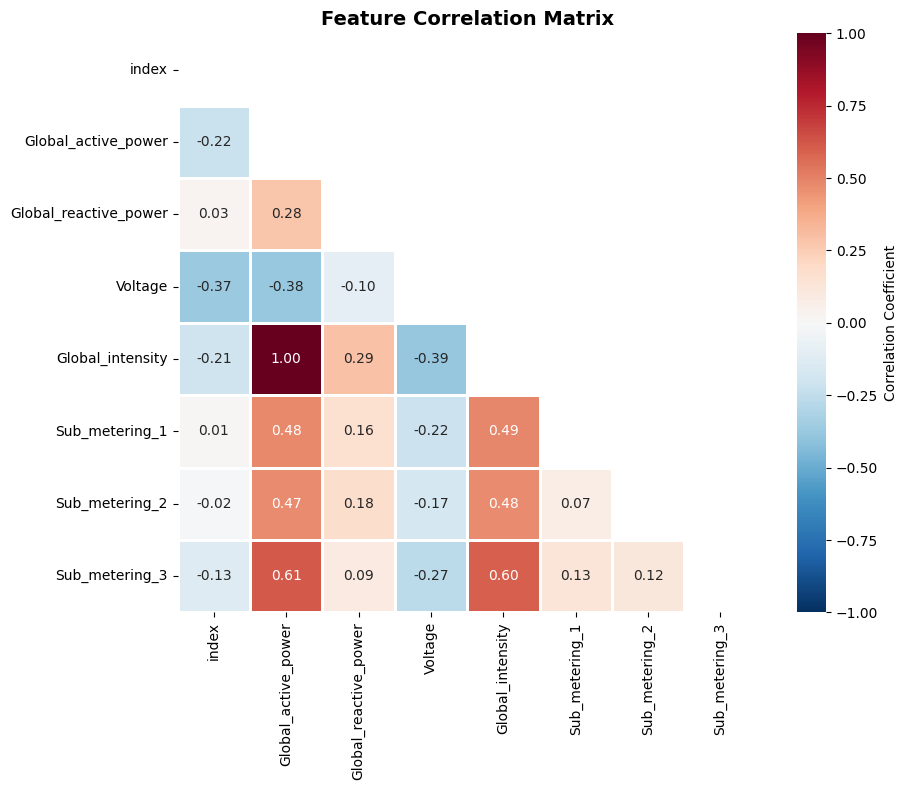


Key Correlations:
   Global_active_power <-> Global_intensity: 0.999
   Global_active_power <-> Voltage:          -0.375
   Global_active_power <-> Sub_metering_3:   0.609
   Voltage <-> Global_intensity:              -0.386


In [16]:
# CELL 12: Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, ax=ax,
            vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('/kaggle/working/dqr_section6_correlatoin.png',
            dpi=300, bbox_inches='tight')

plt.show()

print('\nKey Correlations:')
print(f'   Global_active_power <-> Global_intensity: {corr.loc["Global_active_power","Global_intensity"]:.3f}')
print(f'   Global_active_power <-> Voltage:          {corr.loc["Global_active_power","Voltage"]:.3f}')
print(f'   Global_active_power <-> Sub_metering_3:   {corr.loc["Global_active_power","Sub_metering_3"]:.3f}')
print(f'   Voltage <-> Global_intensity:              {corr.loc["Voltage","Global_intensity"]:.3f}')

## SECTION 7: Recommendation

In [17]:
# CELL 13: DQR SECTION 7 — Recommendation
print('''
This dataset IS suitable for load forecasting.

REASONS FOR SUITABILITY:

  1. CLEAR TEMPORAL PATTERNS
     Strong daily load cycle visible - low consumption at night
     (2-6 AM), peaks in morning (7-9 AM) and evening (18-21 PM).
     These are exactly the patterns ARIMA captures well.

  2. HIGH RESOLUTION DATA
     Minute-level granularity with ~260K records provides more
     than enough data density for ML training. Can be resampled
     to hourly (aligned with Pulse 24-hour forecasting window).

  3. SUFFICIENT DURATION
     ~6 months covers multiple weekly cycles and seasonal trends.
     Enough for a reliable chronological 80/20 train/test split
     (first ~5 months train, last ~1 month test).

  4. RELEVANT TARGET VARIABLE
     Global_active_power maps directly to electrical load (kW).
     This is the core variable PulsePredict is designed to forecast.

  5. MANAGEABLE MISSING DATA
     Missing values exist but are consistently distributed and
     below critical thresholds. Forward-fill or interpolation
     will handle them cleanly.

  6. RICH FEATURE SET
     Sub-metering data provides load decomposition by appliance
     group. Voltage and current data add physical context.

CAVEATS & LIMITATIONS:

  1. HOUSEHOLD-LEVEL, NOT GRID-LEVEL
     This is a single household in France, not a regional grid.
     Values are in kW, not MW. Scaling context needed for Pulse
     grid-level predictions (but patterns are transferable).

  2. 6 MONTHS ONLY
     Does not cover full-year seasonality. No winter heating data.
     Models may underperform on unseen seasonal patterns.

  3. NO EXTERNAL COVARIATES
     No weather, temperature, or holiday data included. ARIMA is
     fine (univariate), but XGBoost would benefit from external
     features. Can be augmented post-MVP.

PREPROCESSING REQUIRED FOR PULSE COMPATIBILITY:
  - Resample from minute to hourly (align with Pulse forecasting)
  - Forward-fill or interpolate missing values
  - Map: Global_active_power -> load_mw concept
  - Add: region="FR-01", source="KAGGLE" for Pulse Data Schema
''')


This dataset IS suitable for load forecasting.

REASONS FOR SUITABILITY:

  1. CLEAR TEMPORAL PATTERNS
     Strong daily load cycle visible - low consumption at night
     (2-6 AM), peaks in morning (7-9 AM) and evening (18-21 PM).
     These are exactly the patterns ARIMA captures well.

  2. HIGH RESOLUTION DATA
     Minute-level granularity with ~260K records provides more
     than enough data density for ML training. Can be resampled
     to hourly (aligned with Pulse 24-hour forecasting window).

  3. SUFFICIENT DURATION
     ~6 months covers multiple weekly cycles and seasonal trends.
     Enough for a reliable chronological 80/20 train/test split
     (first ~5 months train, last ~1 month test).

  4. RELEVANT TARGET VARIABLE
     Global_active_power maps directly to electrical load (kW).
     This is the core variable PulsePredict is designed to forecast.

  5. MANAGEABLE MISSING DATA
     Missing values exist but are consistently distributed and
     below critical threshold

In [18]:
# CELL 14: Final Summary
print('=' * 60)
print('DATA QUALITY REPORT - FINAL SUMMARY')
print('=' * 60)

print(f'''
  PULSE - Week 1 Data Quality Report
  Intern: Mubashir
  Team:   Research / ML / AI - ARIMA Sub-team

  Dataset:      240K+ Household Electricity Consumption
  Source:       Kaggle (Hebrail & Berard)
  Records:      {len(df):,} measurements
  Time Range:   {str(df.index.min())[:10]} to {str(df.index.max())[:10]}
  Resolution:   1-minute intervals
  Variables:    {len(df.columns)} numeric features
  Missing:      See Section 4 analysis
  Anomalies:    {len(anomalies)} types identified

  VERDICT:      SUITABLE for load forecasting
                (with preprocessing - see Section 7)

  Commit: "Week 1 DQR: mubashir - Kaggle Household
           Electricity Consumption"
''')

print('Report complete. Ready for review.')

DATA QUALITY REPORT - FINAL SUMMARY

  PULSE - Week 1 Data Quality Report
  Intern: Mubashir
  Team:   Research / ML / AI - ARIMA Sub-team

  Dataset:      240K+ Household Electricity Consumption
  Source:       Kaggle (Hebrail & Berard)
  Records:      260,640 measurements
  Time Range:   2007-01-01 to 2007-06-30
  Resolution:   1-minute intervals
  Variables:    8 numeric features
  Missing:      See Section 4 analysis
  Anomalies:    2 types identified

  VERDICT:      SUITABLE for load forecasting
                (with preprocessing - see Section 7)

  Commit: "Week 1 DQR: mubashir - Kaggle Household
           Electricity Consumption"

Report complete. Ready for review.
